# T09

## CONCEPTUAL

### 1

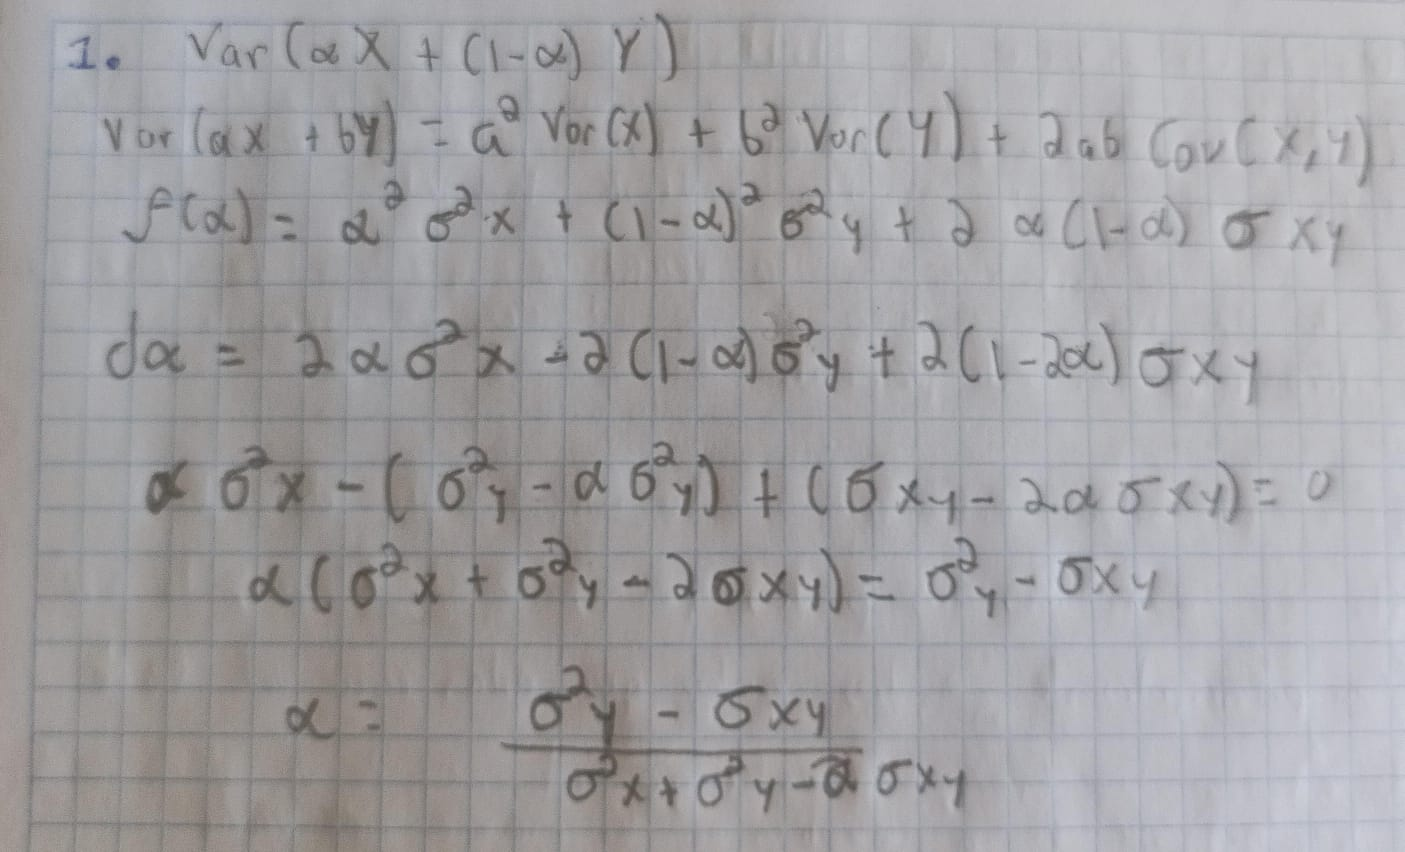

### 2.

a) En un conjunto de $n$ observaciones, la probabilidad de seleccionar una observación específica es 1/n. Por lo tanto, la probabilidad de no seleccionarla es el complemento: $$1 - \frac{1}{n}$$

b) Como el muestreo es con reemplazo, cada selección es independiente. La probabilidad sigue siendo la misma que en el inciso anterior: $$1 - \frac{1}{n}$$

c) Una muestra bootstrap consiste en realizar n selecciones independientes. Para que la observación no aparezca en toda la muestra, no debe ser elegida en ninguna de las n veces = $$P(\text{no en la muestra}) = \left(1 - \frac{1}{n}\right)^n$$

d) La probabilidad de que sí esté es $1 - P(\text{de que no esté})$:
  $$1 - (1 - 1/5)^5 = 1 - (0.8)^5 = 0.67232$$

e) Cuando $n = 100$ $$1 - (1 - 1/100)^{100} = 1 - 0.36603 = 0.63397$$

f) Cuando $n = 10,000$ $$1 - (1 - 1/10,000)^{10,000} \approx 0.63213$$

g) A medida que n aumenta, la probabilidad $1 - (1 - 1/n)^n$ converge rápidamente a un valor constante. $$\lim_{n \to \infty} (1 - 1/n)^n = e^{-1} \approx 0.3678$$ Por lo tanto, la probabilidad de que una observación sea parte de una muestra bootstrap es aproximadamente $1 - 1/e \approx \mathbf{0.632}$. En promedio, una muestra bootstrap contiene cerca del 63.2% de los datos originales


In [15]:
# h)
import numpy as np
import matplotlib.pyplot as plt

# --- Parte (h): Simulación numérica ---
rng = np.random.default_rng(10)
store = np.empty(10000)

for i in range(10000):
    # Generamos muestra bootstrap de tamaño 100 de un rango 0-99
    bootstrap_sample = rng.choice(100, size=100, replace=True)
    # Verificamos si la observación '4' está presente
    store[i] = np.any(bootstrap_sample == 4)

print(f"Probabilidad simulada (n=100): {np.mean(store):.4f}")


Probabilidad simulada (n=100): 0.6362


h) El valor obtenido en la simulación (np.mean(store)) debe ser muy cercano a 0.632, lo que confirma experimentalmente la derivación matemática que se hizo en los ejercicios pasados

### 3

a) k-fold Cross-Validation

1. División de datos: Los datos se dividen aleatoriamente en k grupos de tamaños similares
2. Iteraciones: Cada iteración un grupo se dejafuera para que sea como las pruebas, Utiliza todos los otros k-foldd para entrenar el modelo y sacar las métricas.
3. Resultado final: Promedio total de todas las metricas obtenidas

b) Ventajas y desventajas

- Ventaja i = Nos ayusa a reducir mucho sesgo sobre los datos y ver que obtuvimos la mejor combinación de datos posibles para entrenar el modelo

- Desventaja i = Requiere entrenar el modelo k veces, con una base de datos pesada puede ser tardado

- Ventaja ii = Puede ser mucho más rapido a comparación de LOOCV

- Desventaja ii = El sesgo puede ser un poco más alto que en LOOCV, aunque la ganancia en varianza suele compensarlo.

### 4. Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X. Carefully describe how we might estimate the standard deviation of our prediction.

- Primero generamos muestras de bootstrap, que sea muestras con reemplazo. 
- Después entrenamos el modelo, esto dara B estimaciones diferentes de nuestra función predicción
- Utilizamos cada uno de los B para hacer las predicciones en el punto específico de interés
- Ya con la lista de valores predichos calculamos la desviación estándar de estas predicciones. 

## Aplicación

### 5

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

df = pd.read_csv('Default.csv')

# Preprocesamiento: Convertir 'Yes'/'No' a 1/0
df['default_num'] = (df['default'] == 'Yes').astype(int)
df['student_num'] = (df['student'] == 'Yes').astype(int)

# a) Ajustar un modelo de regresión logística con todos los datos
# Definimos X (agregando la constante para el intercepto) e y
X_full = sm.add_constant(df[['income', 'balance']])
y_full = df['default_num']

model_full = sm.Logit(y_full, X_full).fit()
print("--- Resumen del modelo completo ---")
print(model_full.summary())

# b) Función para el Enfoque del Conjunto de Validación
def estimate_test_error(seed, include_student=False):
    # i. Dividir la muestra (50% train, 50% validation)
    train, val = train_test_split(df, test_size=0.5, random_state=seed)
    
    # Definir variables predictoras
    features = ['income', 'balance']
    if include_student:
        features.append('student_num')
    
    # ii. Ajustar modelo usando solo entrenamiento
    X_train = sm.add_constant(train[features])
    y_train = train['default_num']
    model_train = sm.Logit(y_train, X_train).fit(disp=0) # disp=0 para no saturar la consola
    
    # iii. Obtener predicciones para el conjunto de validación
    X_val = sm.add_constant(val[features])
    y_val = val['default_num']
    
    # Probabilidades posteriores
    probs = model_train.predict(X_val)
    # Clasificar si prob > 0.5[cite: 1]
    predictions = (probs > 0.5).astype(int)
    
    # iv. Calcular el error de validación (fracción de errores)[cite: 1]
    test_error = np.mean(predictions != y_val)
    return test_error

# Ejecutar parte b)
error_b = estimate_test_error(seed=1)
print(f"\nError de validación (Parte b): {error_b:.4%}")

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10
--- Resumen del modelo completo ---
                           Logit Regression Results                           
Dep. Variable:            default_num   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.4594
Time:                        11:22:43   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     

In [17]:
# c) Repetir tres veces con diferentes particiones[cite: 1]
print("\n--- Repeticiones con diferentes semillas ---")
for s in [42, 123, 2024]:
    err = estimate_test_error(seed=s)
    print(f"Semilla {s}: Error = {err:.4%}")


--- Repeticiones con diferentes semillas ---
Semilla 42: Error = 2.5800%
Semilla 123: Error = 2.5600%
Semilla 2024: Error = 2.7000%


In [18]:
# d) ¿Incluir 'student' reduce el error?
error_with_student = estimate_test_error(seed=1, include_student=True)
print(f"\nError incluyendo 'student': {error_with_student:.4%}")
print(f"Diferencia: {error_b - error_with_student:.4%}")


Error incluyendo 'student': 2.6200%
Diferencia: -0.1200%


### 6

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Cargar y preparar datos
df = pd.read_csv('Default.csv')
df['default_num'] = (df['default'] == 'Yes').astype(int)

# a) Errores estándar
X = sm.add_constant(df[['income', 'balance']])
y = df['default_num']

model_glm = sm.GLM(y, X, family=sm.families.Binomial()).fit()

print("a) Errores Estándar Teóricos")
print(model_glm.bse)

# b) Función para el Bootstrap
def boot_fn(data, index):
    df_boot = data.iloc[index]
    
    X_boot = sm.add_constant(df_boot[['income', 'balance']])
    y_boot = df_boot['default_num']
    
    # Ajustamos el modelo (disp=0 para evitar mensajes en cada iteración)
    model = sm.Logit(y_boot, X_boot).fit(disp=0)
    return model.params[['income', 'balance']]


# c) Ejecutar el Bootstrap
def run_bootstrap(data, n_iterations=1000):
    rng = np.random.default_rng(42)
    n = len(data)
    boot_results = []
    
    for _ in range(n_iterations):
        idx = rng.choice(n, size=n, replace=True)
        boot_results.append(boot_fn(data, idx))
    
    # Convertimos a DataFrame para calcular la desviación estándar
    boot_df = pd.DataFrame(boot_results)
    return boot_df.std()

# Obtenemos los errores estándar por bootstrap
boot_se = run_bootstrap(df)

print("\n c) Errores Estándar por Bootstrap")
print(boot_se)



a) Errores Estándar Teóricos
const      0.434772
income     0.000005
balance    0.000227
dtype: float64

 c) Errores Estándar por Bootstrap
income     0.000005
balance    0.000236
dtype: float64


In [21]:

# d) Comparación de resultados
print("\n d) Comparación de resultados")
comparison = pd.DataFrame({
    'Teórico (GLM)': model_glm.bse[['income', 'balance']],
    'Bootstrap': boot_se
})
print(comparison)


 d) Comparación de resultados
         Teórico (GLM)  Bootstrap
income        0.000005   0.000005
balance       0.000227   0.000236


### 8.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression

# (a) Generación de datos simulados
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df = pd.DataFrame({'X': x, 'Y': y})



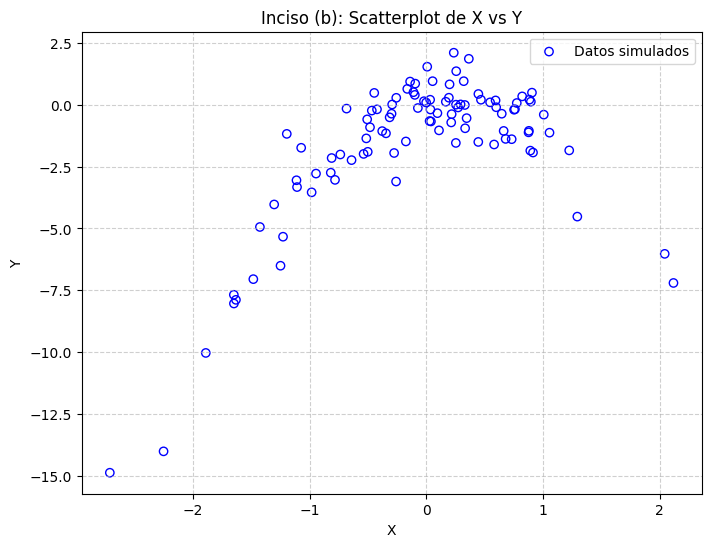

In [34]:
# (b) Gráfica de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], facecolors='none', edgecolors='blue', label='Datos simulados')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Inciso (b): Scatterplot de X vs Y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [35]:
# Función para calcular LOOCV
def calculate_loocv(data, seed_val):
    loo = LeaveOneOut()
    model = LinearRegression()
    mse_errors = []
    
    for i in range(1, 5):
        # Crear matriz de diseño para polinomios: X, X^2, X^3, X^4
        X_poly = np.column_stack([data['X']**j for j in range(1, i+1)])
        
        # cross_val_score usa MSE negativo por defecto, lo convertimos a positivo
        scores = cross_val_score(model, X_poly, data['Y'], 
                                 scoring='neg_mean_squared_error', cv=loo)
        mse_errors.append(np.mean(np.abs(scores)))
    return mse_errors

# (c) Cómputo de errores con Semilla 1
errors_c = calculate_loocv(df, 1)
print("--- Inciso (c): Errores LOOCV (Semilla 1) ---")
for i, err in enumerate(errors_c, 1):
    print(f"Modelo {i} (Grado {i}): {err:.4f}")

--- Inciso (c): Errores LOOCV (Semilla 1) ---
Modelo 1 (Grado 1): 6.6330
Modelo 2 (Grado 2): 1.1229
Modelo 3 (Grado 3): 1.3018
Modelo 4 (Grado 4): 1.3324


In [37]:
# (d) Cómputo de errores con Semilla 42 (otra semilla)
errors_d = calculate_loocv(df, 42)
print("\n--- Inciso (d): Errores LOOCV (Semilla 42) ---")
for i, err in enumerate(errors_d, 1):
    print(f"Modelo {i} (Grado {i}): {err:.4f}")


--- Inciso (d): Errores LOOCV (Semilla 42) ---
Modelo 1 (Grado 1): 6.6330
Modelo 2 (Grado 2): 1.1229
Modelo 3 (Grado 3): 1.3018
Modelo 4 (Grado 4): 1.3324


In [38]:
# (f) Significancia estadística de los coeficientes[cite: 1]
print("\n--- Inciso (f): Resumen Estadístico (Modelo iv - Grado 4) ---")
# Preparamos las columnas para el modelo de grado 4
X_iv = np.column_stack([df['X']**j for j in range(1, 5)])
X_sm = sm.add_constant(X_iv) # Añadir intercepto
model_final = sm.OLS(df['Y'], X_sm).fit()

# Imprimir solo los p-values para claridad, o el resumen completo
print(model_final.summary())


--- Inciso (f): Resumen Estadístico (Modelo iv - Grado 4) ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     200.2
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.22e-45
Time:                        11:43:42   Log-Likelihood:                -137.74
No. Observations:                 100   AIC:                             285.5
Df Residuals:                      95   BIC:                             298.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

### 9.

In [41]:
import pandas as pd
import numpy as np

# 1. Cargar datos del archivo Excel proporcionado
df = pd.read_excel('Boston Housing Dataset 1978.xlsx')
medv = df['MEDV'].dropna().values # Limpiar nulos por seguridad

# (a) Media de medv
mu_hat = np.mean(medv)
print(f"(a) Estimación de la media (mu_hat): {mu_hat:.4f}")

(a) Estimación de la media (mu_hat): 23.7504


In [42]:
# (b) SE Teórico de la media
n = len(medv)
se_theory = np.std(medv, ddof=1) / np.sqrt(n)
print(f"(b) Error Estándar Teórico: {se_theory:.4f}")

(b) Error Estándar Teórico: 0.4143


In [43]:
# Función auxiliar para Bootstrap
def get_se_bootstrap(data, func, iterations=1000):
    rng = np.random.default_rng(1)
    estimates = [func(rng.choice(data, size=len(data), replace=True)) for _ in range(iterations)]
    return np.std(estimates)

# (c) SE Bootstrap de la media
se_boot = get_se_bootstrap(medv, np.mean)
print(f"(c) Error Estándar Bootstrap: {se_boot:.4f}")

(c) Error Estándar Bootstrap: 0.4119


In [44]:
# (d) Intervalo de Confianza 95%
ci = [mu_hat - 2*se_boot, mu_hat + 2*se_boot]
print(f"(d) 95% CI (Bootstrap): [{ci[0]:.4f}, {ci[1]:.4f}]")

# (e) Mediana
median_hat = np.median(medv)
print(f"(e) Estimación de la mediana: {median_hat:.4f}")

(d) 95% CI (Bootstrap): [22.9267, 24.5742]
(e) Estimación de la mediana: 21.9500


In [45]:
# (f) SE Bootstrap de la mediana
se_med_boot = get_se_bootstrap(medv, np.median)
print(f"(f) SE Bootstrap de la mediana: {se_med_boot:.4f}")

# (g) Percentil 10
p10_hat = np.percentile(medv, 10)
print(f"(g) Estimación del percentil 10: {p10_hat:.4f}")

# (h) SE Bootstrap del percentil 10
se_p10_boot = get_se_bootstrap(medv, lambda x: np.percentile(x, 10))
print(f"(h) SE Bootstrap del percentil 10: {se_p10_boot:.4f}")

(f) SE Bootstrap de la mediana: 0.3015
(g) Estimación del percentil 10: 14.5000
(h) SE Bootstrap del percentil 10: 0.4209
